In [39]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf 


from tensorflow import keras
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential

In [40]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin = dataset_url, cache_dir = '.', untar = True)

In [41]:
data_dir

'.\\datasets\\flower_photos'

In [42]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [43]:
len(list(data_dir.glob('*/*.JPG')))        # I don't know why this is not working 

3670

In [44]:
image_count = len(list(data_dir.rglob('*.jpg')))
image_count


7340

In [45]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

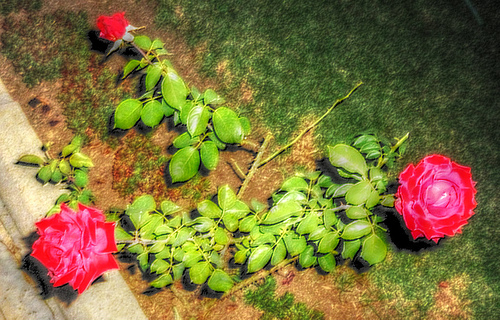

In [46]:
PIL.Image.open(str(roses[95]))

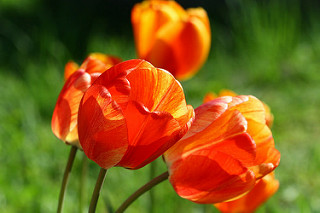

In [47]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[99]))

In [48]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [49]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [50]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [51]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [52]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(240, 179, 3)

In [53]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [54]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [55]:
X = np.array(X)
y = np.array(y)

## train test Solit

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [57]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [ ]:
num_classes = 5              # 5 nurones each crossponding to each flower tier 

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.4891 - loss: 1.2552
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.6272 - loss: 0.9665
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7217 - loss: 0.7494
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.7951 - loss: 0.5478
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8884 - loss: 0.3336
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9295 - loss: 0.2111
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9633 - loss: 0.1258
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9822 - loss: 0.0665
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9938 - loss: 0.0311
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9942 - loss: 0.0275
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9840 - loss: 0.0596
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy:

In [59]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6667 - loss: 2.3245


[2.3244776725769043, 0.6666666865348816]

##### this is an Example of overfitting ; where the model performs better in Training dataset but very less perform in test Dataset 

In [60]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


array([[  8.14219   ,  23.74359   ,  -1.1137971 , -19.916332  ,
          0.8246175 ],
       [ 17.037207  ,   1.3379014 ,  -4.520118  ,  -9.994808  ,
          3.87718   ],
       [  1.3346624 ,   4.2200336 ,  13.673805  , -15.30028   ,
         -3.2342832 ],
       ...,
       [  0.3268036 ,  -8.211376  , -10.265735  ,  12.987069  ,
          4.8796377 ],
       [  7.8779755 ,   2.5929737 ,   5.4011226 ,  -8.8144655 ,
         -0.93484604],
       [  0.87650657, -15.639183  ,   0.78599596,  12.023999  ,
          4.7131596 ]], dtype=float32)

In [66]:
score = tf.nn.softmax(predictions[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([1.67647968e-07, 9.99999881e-01, 1.60167556e-11, 1.09329599e-19,
       1.11279944e-10], dtype=float32)>

In [62]:
np.argmax(score)

np.int64(1)

In [63]:
y_test[0]

np.int64(1)

In [76]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


##### original Image

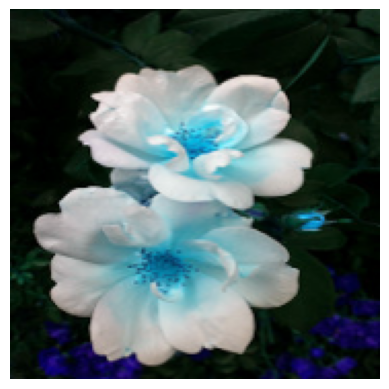

In [72]:
plt.axis('off')
plt.imshow(X[0])

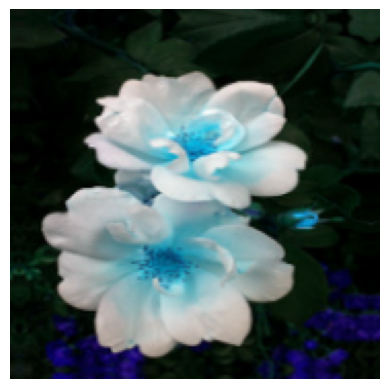

In [73]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [77]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30) 

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.4073 - loss: 1.4274
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.5523 - loss: 1.1045
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.6185 - loss: 0.9760
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.6348 - loss: 0.9362
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.6668 - loss: 0.8712
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.6882 - loss: 0.8126
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7195 - loss: 0.7688
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7184 - loss: 0.7387
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.7257 - loss: 0.7124
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.7362 - loss: 0.6821
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.7562 - loss: 0.6381
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accurac

In [81]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7288 - loss: 0.9512


[0.951174795627594, 0.7287581562995911]

### You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 73.74%